# Directional statistics: data on circles and spheres

Why angles and directions need their own distributions - the arithmetic mean is wrong for circular data (averaging 1° and 359° gives 180°, the opposite direction) - and how to model them: the von Mises distribution on the circle (wind directions, times of day, phases) and the von Mises-Fisher distribution on the sphere (unit vectors, headings, normalized embeddings).


## Why the line does not wrap around the circle

Angles live on the circle, where $0$ and $2\pi$ are the same point, so ordinary arithmetic on their
numerical values is meaningless. The linear average of $350^\circ$ and $10^\circ$ is $180^\circ$, the
exact opposite of the correct answer $0^\circ$. The right summaries embed each angle as a unit vector and
average there.

Definition (resultant and circular mean). For angles $\theta_1,\dots,\theta_n$ let
$C=\tfrac1n\sum\cos\theta_i$, $S=\tfrac1n\sum\sin\theta_i$. The mean resultant length is $\bar R=\sqrt{C^2+S^2}\in[0,1]$
and the circular mean is $\bar\theta=\operatorname{atan2}(S,C)$. Here $\bar R$ measures concentration:
$\bar R\approx 0$ means the directions cancel (no preferred direction), $\bar R\approx 1$ means they
nearly coincide.

## The von Mises distribution

Definition. The von Mises density on the circle is
$p(\theta\mid\mu,\kappa)=\dfrac{1}{2\pi I_0(\kappa)}\exp\!\big(\kappa\cos(\theta-\mu)\big)$, with mean
direction $\mu$, concentration $\kappa\ge 0$, and $I_0$ the modified Bessel function of order zero. It is
the circular analogue of the Gaussian.

Theorem (maximum entropy on the circle). Among all densities on $[0,2\pi)$ with a prescribed mean
direction and resultant length (equivalently, prescribed $\mathbb E[\cos\theta]$ and $\mathbb E[\sin\theta]$),
the von Mises has maximum entropy.

Proof sketch. Maximize $-\int p\log p$ subject to $\int p=1$ and the two trigonometric-moment
constraints; the Lagrange stationarity condition gives $\log p = a + b\cos\theta + c\sin\theta$, which is
the von Mises form after writing $b\cos\theta+c\sin\theta=\kappa\cos(\theta-\mu)$. $\quad\blacksquare$

Theorem (MLE by moment matching). The von Mises MLE sets $\hat\mu=\bar\theta$ and solves
$A(\hat\kappa)=\bar R$, where $A(\kappa)=I_1(\kappa)/I_0(\kappa)$ is the mean-resultant function. This is
the exponential-family moment-matching rule (the canonical statistic is $(\cos\theta,\sin\theta)$).

Theorem (Gaussian limit). For large $\kappa$, $\theta-\mu \approx \mathcal N(0,1/\kappa)$: a concentrated
von Mises is approximately a wrapped Gaussian, so high-concentration circular data behaves like ordinary
data, and the two theories meet.

## Testing for a direction, and the failure of linear statistics

Definition (Rayleigh test). To test the null of uniformity (no preferred direction) against a von Mises
alternative, use $Z=n\bar R^2$; under the null $2Z$ is approximately $\chi^2_2$ for large $n$, with
$p\approx e^{-Z}$ to first order. Reject for large $\bar R$. (We apply it in the applied section.)

Counterexample (the linear mean is not just biased, it can be exactly wrong). Take angles clustered near
$0^\circ$ but straddling the wrap point, for instance $\{350^\circ, 355^\circ, 5^\circ, 10^\circ\}$. The
linear average is $180^\circ$, pointing in precisely the opposite direction, while the circular mean is
$0^\circ$, the correct center. No amount of data fixes the linear estimator; it is the wrong operation.
We make this concrete below, and also check the moment-matching MLE recovers a known concentration.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import VonMisesDistribution, VonMisesEstimator, VonMisesFisherDistribution, VonMisesFisherEstimator
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)

## 1. Why circular data breaks ordinary statistics

Angles live on a circle: $0$ and $2\pi$ are the same point. So the ordinary mean is meaningless - data clustered near $0$ (some at $0.1$, some at $2\pi-0.1$) average to $\approx\pi$, pointing the exact wrong way. The right summary is the circular mean: average the unit vectors $(\cos\theta,\sin\theta)$ and take the angle of the resultant. The von Mises distribution $p(\theta)\propto e^{\kappa\cos(\theta-\mu)}$ is the circle's Gaussian - mean direction $\mu$, concentration $\kappa$ (large $\kappa$ = tight). We make wrap-around data and watch the linear mean fail.


true direction: 0.00 rad
naive linear mean : 3.09 rad  (pulled to the wrong side by wrap-around)
circular mean     : 0.01 rad  (correct)


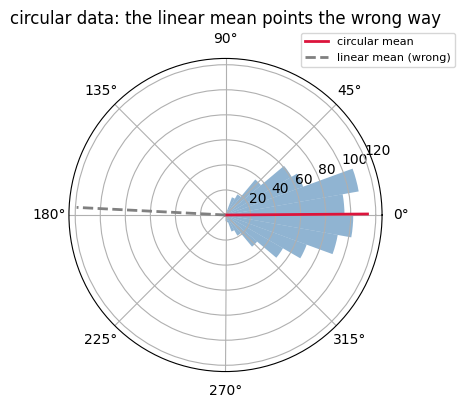

In [2]:
# wind directions clustered around due north (angle 0), straddling the 0 / 2-pi seam
true_mu, true_kappa = 0.0, 4.0
angles = np.asarray(VonMisesDistribution(true_mu, true_kappa).sampler(seed=1).sample(800), float) % (2 * np.pi)

linear_mean = angles.mean()                                   # WRONG near the seam
circular_mean = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean()) % (2 * np.pi)
print('true direction: 0.00 rad')
print('naive linear mean : %.2f rad  (pulled to the wrong side by wrap-around)' % linear_mean)
print('circular mean     : %.2f rad  (correct)' % circular_mean)

fig = plt.figure(figsize=(4.6, 4.6)); ax = fig.add_subplot(111, projection='polar')
ax.hist(angles, bins=36, color='steelblue', alpha=0.6)
ax.plot([circular_mean, circular_mean], [0, ax.get_ylim()[1]], color='crimson', lw=2, label='circular mean')
ax.plot([linear_mean, linear_mean], [0, ax.get_ylim()[1]], color='gray', lw=2, ls='--', label='linear mean (wrong)')
ax.set_title('circular data: the linear mean points the wrong way'); ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=8)
plt.tight_layout(); plt.show()

## 2. Fitting a von Mises distribution

Fitting recovers $\mu$ (mean direction) and $\kappa$ (concentration) by maximum likelihood - which automatically does the circular-mean computation and estimates the spread. We fit and overlay the density on the angular histogram.


Iteration 3: ln[p_mat(Data|Model)]=-6.452070e+02, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
fitted von Mises: mu=0.01 (true 0.00)  kappa=4.01 (true 4.00)


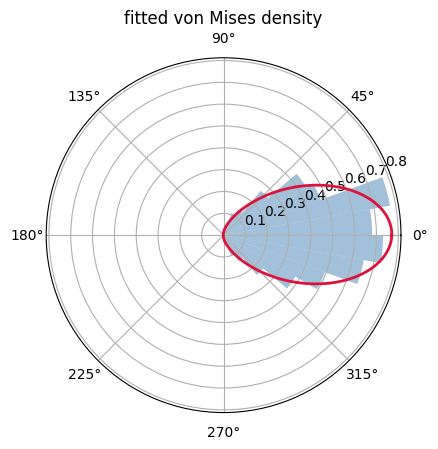

In [3]:
vm = optimize(list(angles), VonMisesEstimator(), max_its=30, rng=rng, print_iter=100)
print('fitted von Mises: mu=%.2f (true %.2f)  kappa=%.2f (true %.2f)' % (vm.mu % (2 * np.pi), true_mu, vm.kappa, true_kappa))

grid = np.linspace(0, 2 * np.pi, 300)
dens = np.exp([vm.log_density(float(t)) for t in grid])
fig = plt.figure(figsize=(4.6, 4.6)); ax = fig.add_subplot(111, projection='polar')
ax.hist(angles, bins=36, density=True, color='steelblue', alpha=0.5)
ax.plot(grid, dens, color='crimson', lw=2)
ax.set_title('fitted von Mises density'); plt.tight_layout(); plt.show()

## 3. The sphere: von Mises-Fisher

Step up a dimension: unit vectors in 3-D (headings, directions of travel, $\ell_2$-normalized feature/embedding vectors) live on the sphere. The von Mises-Fisher distribution is their model - a mean direction $\mu$ (a unit vector) and a concentration $\kappa$. Samples are points on the unit sphere clustered around $\mu$; fitting recovers the mean direction. (This is the distribution behind spherical clustering and directional embeddings.)


all samples are unit vectors: True
Iteration 3: ln[p_mat(Data|Model)]=-4.263898e+02, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
recovered mean direction: [-0.01, -0.02, 1.0] (true [0.0, 0.0, 1.0])  kappa=8.39


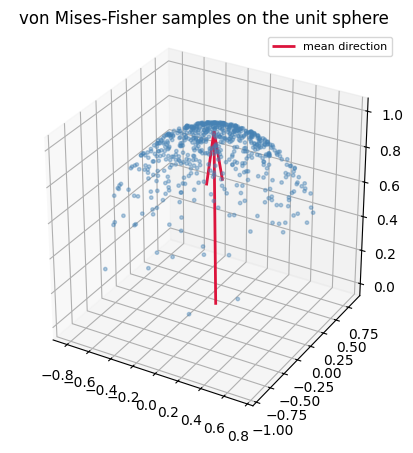

In [4]:
mu_true = np.array([0.0, 0.0, 1.0])                       # the north pole
vmf = VonMisesFisherDistribution(mu_true.tolist(), kappa=8.0)
pts = np.asarray(vmf.sampler(seed=2).sample(size=600), float)
print('all samples are unit vectors:', np.allclose(np.linalg.norm(pts, axis=1), 1.0))

fitted = optimize([list(map(float, p)) for p in pts], VonMisesFisherEstimator(), max_its=30, rng=rng, print_iter=100)
print('recovered mean direction: %s (true %s)  kappa=%.2f' % (np.round(fitted.mu, 2).tolist(), mu_true.tolist(), fitted.kappa))

fig = plt.figure(figsize=(4.8, 4.4)); ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=6, alpha=0.4, color='steelblue')
ax.quiver(0, 0, 0, *fitted.mu, color='crimson', lw=2, label='mean direction')
ax.set_title('von Mises-Fisher samples on the unit sphere'); ax.set_box_aspect((1, 1, 1)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Test for uniformity before modeling

Before fitting a von Mises you should reject the null that the data are uniform on the circle (no preferred direction). The Rayleigh test uses the mean resultant length $\bar R$: under uniformity $Z=n\bar R^2$ is small, and $p\approx e^{-Z}$ (with a small-sample correction). We apply it to our concentrated data (should reject) and to simulated uniform angles (should not).


In [5]:
def rayleigh_test(a):
    a = np.asarray(a); n = len(a)
    R = np.hypot(np.cos(a).mean(), np.sin(a).mean())      # mean resultant length
    Z = n * R ** 2
    p = np.exp(-Z) * (1 + (2 * Z - Z ** 2) / (4 * n) - (24 * Z - 132 * Z ** 2 + 76 * Z ** 3 - 9 * Z ** 4) / (288 * n ** 2))
    return R, p
R, p = rayleigh_test(angles)
print('concentrated data: Rbar=%.3f  Rayleigh p=%.2e  -> reject uniformity (a real direction)' % (R, p))
unif = rng.uniform(0, 2 * np.pi, len(angles))
R0, p0 = rayleigh_test(unif)
print('uniform data     : Rbar=%.3f  Rayleigh p=%.2f  -> correctly does NOT reject' % (R0, p0))

concentrated data: Rbar=0.864  Rayleigh p=2.34e-256  -> reject uniformity (a real direction)
uniform data     : Rbar=0.043  Rayleigh p=0.23  -> correctly does NOT reject


## Illustration: linear versus circular averaging

We compute both averages on angles that straddle the wrap point. The linear mean lands on the opposite
side of the circle while the circular mean is correct, and the discrepancy does not shrink with more
data because the linear operation is simply inappropriate on the circle.

In [6]:
rng = np.random.RandomState(0)
deg = np.array([350., 355., 5., 10.])
ang = np.deg2rad(deg)
lin = deg.mean()
circ = (np.rad2deg(np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())) + 180) % 360 - 180
print('angles (degrees): %s' % deg.tolist())
print('linear mean   = %.1f deg  (points the wrong way)' % lin)
print('circular mean = %.1f deg  (correct: the cluster is centered near 0)' % circ)
# moment-matching MLE recovers a known concentration
from scipy.special import i0, i1
from scipy.optimize import brentq
kappa_true = 4.0
th = (rng.vonmises(0.0, kappa_true, 5000)) % (2 * np.pi)
Rbar = np.hypot(np.cos(th).mean(), np.sin(th).mean())
kappa_hat = brentq(lambda k: i1(k) / i0(k) - Rbar, 1e-6, 200)
print('von Mises concentration: true kappa=%.1f, MLE (solving I1/I0 = Rbar=%.3f) = %.2f' %
      (kappa_true, Rbar, kappa_hat))

angles (degrees): [350.0, 355.0, 5.0, 10.0]
linear mean   = 180.0 deg  (points the wrong way)
circular mean = 0.0 deg  (correct: the cluster is centered near 0)
von Mises concentration: true kappa=4.0, MLE (solving I1/I0 = Rbar=0.868) = 4.13


## References

- Mardia, K. V. & Jupp, P. E. (2000). Directional Statistics. Wiley. - the comprehensive reference.
- Fisher, N. I. (1993). Statistical Analysis of Circular Data. Cambridge University Press.
- Banerjee, A., Dhillon, I. S., Ghosh, J. & Sra, S. (2005). Clustering on the unit hypersphere using von Mises-Fisher distributions (https://jmlr.org/papers/v6/banerjee05a.html). JMLR 6, 1345-1382.
- Sra, S. (2012). A short note on parameter approximation for von Mises-Fisher distributions (https://doi.org/10.1007/s00180-011-0232-x). Comput. Statist. 27, 177-190.


## Exercises and extensions

1. Concentration estimation. The vMF MLE for $\kappa$ has no closed form (it involves a ratio of Bessel functions). Implement the Banerjee et al. (2005) approximation and Sra's (2012) Newton refinement, and compare both to a numerical MLE across dimensions and true $\kappa$. Plot the bias of each.
2. Mixtures on the sphere. Implement EM for a mixture of von Mises-Fisher distributions (Banerjee et al.) and cluster $\ell_2$-normalized text/image embeddings; compare to spherical k-means (its hard-assignment limit) by adjusted Rand index. Show where soft vMF assignment helps.
3. Bimodal time-of-day data. Map event timestamps to angles and fit a mixture of two von Mises components for a morning/evening rhythm; compare to a single von Mises by held-out likelihood and a circular posterior-predictive check. (Connects to bayesian_tweet_rhythm.)
4. Tests of uniformity and goodness-of-fit. Implement the Rayleigh test and Kuiper's test for circular uniformity, and a circular Q-Q plot against the fitted von Mises; apply to a dataset that is almost uniform and discuss power.
